In [ ]:
import torch
import ultralytics

In [ ]:
def check_cuda_availability():
    if torch.cuda.is_available():
        print("CUDA is available.")
        print(f"CUDA Device Name: {torch.cuda.get_device_name(0)}")
        print(f"CUDA Device Count: {torch.cuda.device_count()}")
    else:
        print("CUDA is not available.")

# Call the function
check_cuda_availability()

#### Split Dataset

In [ ]:
train_data = "dataset/train"
val_data = "dataset/val"
test_data = "dataset/test"

# Ensure the output directories exist
os.makedirs(train_data, exist_ok=True)
os.makedirs(val_data, exist_ok=True)
os.makedirs(test_data, exist_ok=True)

# Split dataset
for class_folder in os.listdir(experiment_dataset):
    class_path = os.path.join(experiment_dataset, class_folder)
    if os.path.isdir(class_path):
        # Get all files in the class folder
        files = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
        
        # Split into 70% train, 15% validation, and 15% test
        train_files, temp_files = train_test_split(files, test_size=0.3, random_state=42)
        val_files, test_files = train_test_split(temp_files, test_size=0.5, random_state=42)
        
        # Create class subdirectories in train, val, and test folders
        train_class_dir = os.path.join(train_data, class_folder)
        val_class_dir = os.path.join(val_data, class_folder)
        test_class_dir = os.path.join(test_data, class_folder)
        os.makedirs(train_class_dir, exist_ok=True)
        os.makedirs(val_class_dir, exist_ok=True)
        os.makedirs(test_class_dir, exist_ok=True)
        
        # Move files to train, val, and test directories
        for file in train_files:
            shutil.copy(os.path.join(class_path, file), os.path.join(train_class_dir, file))
        
        for file in val_files:
            shutil.copy(os.path.join(class_path, file), os.path.join(val_class_dir, file))
        
        for file in test_files:
            shutil.copy(os.path.join(class_path, file), os.path.join(test_class_dir, file))

print("Dataset split complete.")


#### Train 

In [ ]:
from ultralytics import YOLO

model_path = 'yolov8n-cls.pt'

def load_model_on_cuda(model_path):
    # Load the model
    model = YOLO(model_path)
    
    # Check if CUDA is available
    if torch.cuda.is_available():
        device = torch.device('cuda')
        model.to(device)
        print(f"Model moved to {device}")
    else:
        device = torch.device('cpu')
        print(f"CUDA not available, using {device}")

    return model

model = load_model_on_cuda(model_path)

In [ ]:
results = model.train(data='dataset/',epochs=10, imgsz= 640, device=0)

#### Evaluation

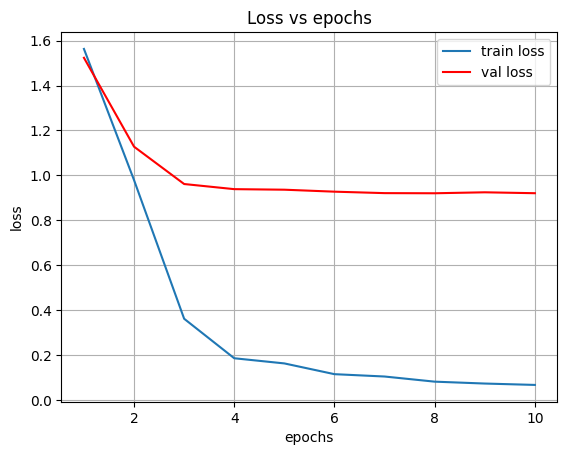

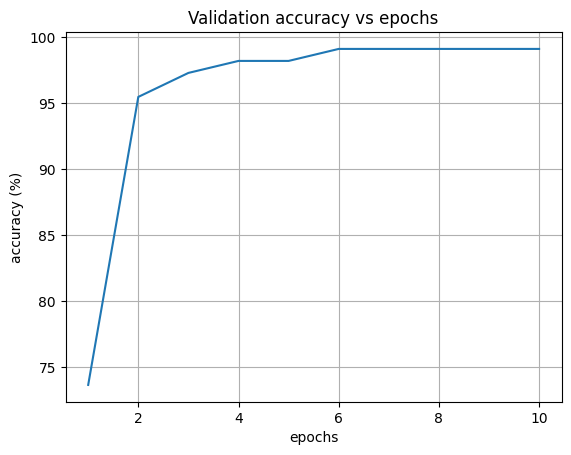

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt


results_path = 'runs/classify/train/results.csv'

results = pd.read_csv(results_path)

plt.figure()
plt.plot(results['                  epoch'], results['             train/loss'], label='train loss')
plt.plot(results['                  epoch'], results['               val/loss'], label='val loss', c='red')
plt.grid()
plt.title('Loss vs epochs')
plt.ylabel('loss')
plt.xlabel('epochs')
plt.legend()


plt.figure()
plt.plot(results['                  epoch'], results['  metrics/accuracy_top1'] * 100)
plt.grid()
plt.title('Validation accuracy vs epochs')
plt.ylabel('accuracy (%)')
plt.xlabel('epochs')

plt.show()

In [10]:
from ultralytics import YOLO
from sklearn.metrics import classification_report
import os
import shutil
from sklearn.model_selection import train_test_split

experiment_dataset = r"D:\Snapfolia Dataset\5CLASS_150IMG"

def get_classes_from_directory(directory):
    return sorted([d.name for d in os.scandir(directory) if d.is_dir()])

def print_number_of_classes(directory):
    classes = get_classes_from_directory(directory)
    print(f"Number of classes: {len(classes)}")
    print(f"Classes: {classes}")
    return classes
    
def generate_classification_report(run_dir, data_dir, classes):
    # Load the model
    model = YOLO(f'{run_dir}/weights/best.pt')
    
    # Prepare the test dataset
    test_dir = os.path.join(data_dir, 'test')
    test_images = []
    test_labels = []
    for class_id, class_name in enumerate(classes):
        class_dir = os.path.join(test_dir, class_name)
        for image_name in os.listdir(class_dir):
            image_path = os.path.join(class_dir, image_name)
            test_images.append(image_path)
            test_labels.append(class_id)
    
    # Predict and collect results
    y_true = []
    y_pred = []
    for image_path, label in zip(test_images, test_labels):
        predict = model(image_path)
        probs = predict[0].probs.data.tolist()
        predicted_class = np.argmax(probs)
        
        y_true.append(label)
        y_pred.append(predicted_class)
    
    # Debugging output
    print(f"Unique classes in y_true: {np.unique(y_true)}")
    print(f"Unique classes in y_pred: {np.unique(y_pred)}")
    
    # Generate classification report
    report = classification_report(y_true, y_pred, target_names=classes)
    print(report)

    return y_true, y_pred

y_true, y_pred = generate_classification_report('runs/classify/train', "dataset/", classes)


image 1/1 F:\snapfolia\dataset\test\Balete\env_Balete C (63).jpg: 640x640 Balete 1.00, Kamagong 0.00, Native Talisay 0.00, Mangga 0.00, Lansones 0.00, 16.0ms
Speed: 63.7ms preprocess, 16.0ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 F:\snapfolia\dataset\test\Balete\env_Balete D (31).jpg: 640x640 Balete 1.00, Mangga 0.00, Native Talisay 0.00, Lansones 0.00, Kamagong 0.00, 16.0ms
Speed: 67.0ms preprocess, 16.0ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 F:\snapfolia\dataset\test\Balete\env_Balete DD (17).jpg: 640x640 Balete 1.00, Kamagong 0.00, Mangga 0.00, Lansones 0.00, Native Talisay 0.00, 40.0ms
Speed: 70.0ms preprocess, 40.0ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 F:\snapfolia\dataset\test\Balete\env_Balete GG (9).jpg: 640x640 Balete 1.00, Lansones 0.00, Kamagong 0.00, Mangga 0.00, Native Talisay 0.00, 16.0ms
Speed: 31.6ms preprocess, 16.0ms inference, 0.0ms postprocess per ima

In [11]:
from ultralytics import YOLO
from sklearn.metrics import classification_report
import os
import numpy as np

# Helper function to load classes from a directory
def get_classes_from_directory(directory):
    return sorted([d.name for d in os.scandir(directory) if d.is_dir()])

# Function to generate a classification report
def generate_classification_report(y_true, y_pred, classes):
    """
    Generates a classification report.
    """
    report = classification_report(y_true, y_pred, target_names=classes)
    print("Classification Report:")
    print(report)
    return report

In [12]:
# Function to compute AP and mAP
from sklearn.metrics import average_precision_score
import numpy as np

def compute_ap_and_map(y_true, y_pred_prob, classes):
    """
    Computes Average Precision (AP) for each class and Mean Average Precision (mAP).
    """
    ap_scores = []
    for i in range(len(classes)):
        ap = average_precision_score(y_true == i, y_pred_prob[:, i])
        ap_scores.append(ap)
    
    map_score = np.mean(ap_scores)
    print(f"Mean Average Precision (mAP): {map_score:.4f}")
    return ap_scores, map_score

In [13]:
# Function to compute AUC (Area Under Curve) score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

def compute_auc(y_true, y_pred_prob, classes):
    """
    Computes AUC (Area Under Curve) score.
    """
    y_true_bin = label_binarize(y_true, classes=np.arange(len(classes)))  # Binarize labels for AUC
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_pred_prob.ravel())
    auc_score = auc(fpr, tpr)
    print(f"AUC: {auc_score:.4f}")
    return auc_score

In [14]:
# Function to compute Log Loss (Cross-Entropy Loss)
from sklearn.metrics import log_loss
import numpy as np

def compute_log_loss(y_true, y_pred_prob):
    """
    Computes Log Loss (Cross-Entropy Loss).
    """
    logloss = log_loss(y_true, y_pred_prob)
    print(f"Log Loss: {logloss:.4f}")
    return logloss

In [15]:
# Function to compute Top-K Accuracy
import numpy as np

def compute_top_k_accuracy(y_true, y_pred_prob, top_k=3):
    """
    Computes Top-K Accuracy.
    """
    top_k_accuracy = np.mean([true_label in np.argsort(probs)[-top_k:] for true_label, probs in zip(y_true, y_pred_prob)])
    print(f"Top-{top_k} Accuracy: {top_k_accuracy:.4f}")
    return top_k_accuracy

In [16]:
# Main function to run everything: Generate metrics
def generate_classification_metrics(run_dir, data_dir, classes, top_k=3):
    # Load the model
    model = YOLO(f'{run_dir}/weights/best.pt')
    
    # Prepare the test dataset
    test_dir = os.path.join(data_dir, 'test')
    test_images = []
    test_labels = []
    for class_id, class_name in enumerate(classes):
        class_dir = os.path.join(test_dir, class_name)
        for image_name in os.listdir(class_dir):
            image_path = os.path.join(class_dir, image_name)
            test_images.append(image_path)
            test_labels.append(class_id)
    
    # Predict and collect results
    y_true = []
    y_pred = []
    y_pred_prob = []  # To store predicted probabilities for AUC and Log Loss
    
    for image_path, label in zip(test_images, test_labels):
        predict = model(image_path)
        probs = predict[0].probs.data.tolist()
        
        predicted_class = np.argmax(probs)
        y_true.append(label)
        y_pred.append(predicted_class)
        y_pred_prob.append(probs)  # Store the probabilities for log_loss and AUC
    
    # Convert to numpy arrays for easier manipulation
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_pred_prob = np.array(y_pred_prob)
    
    # Generate Classification Report
    generate_classification_report(y_true, y_pred, classes)
    
    # Compute AP and mAP
    ap_scores, map_score = compute_ap_and_map(y_true, y_pred_prob, classes)
    
    # Compute AUC
    auc_score = compute_auc(y_true, y_pred_prob, classes)
    
    # Compute Log Loss
    logloss = compute_log_loss(y_true, y_pred_prob)
    
    # Compute Top-K Accuracy
    top_k_accuracy = compute_top_k_accuracy(y_true, y_pred_prob, top_k)
    
    return y_true, y_pred, ap_scores, map_score, auc_score, logloss, top_k_accuracy

In [17]:
experiment_dataset = r"D:\Snapfolia Dataset\5CLASS_150IMG"

classes = get_classes_from_directory(experiment_dataset)

y_true, y_pred, ap_scores, map_score, auc_score, logloss, top_k_accuracy = generate_classification_metrics(
    'runs/classify/train', "dataset/", classes, top_k=3
)


image 1/1 F:\snapfolia\dataset\test\Balete\env_Balete C (63).jpg: 640x640 Balete 1.00, Kamagong 0.00, Native Talisay 0.00, Mangga 0.00, Lansones 0.00, 16.0ms
Speed: 65.0ms preprocess, 16.0ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 F:\snapfolia\dataset\test\Balete\env_Balete D (31).jpg: 640x640 Balete 1.00, Mangga 0.00, Native Talisay 0.00, Lansones 0.00, Kamagong 0.00, 16.0ms
Speed: 73.0ms preprocess, 16.0ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 F:\snapfolia\dataset\test\Balete\env_Balete DD (17).jpg: 640x640 Balete 1.00, Kamagong 0.00, Mangga 0.00, Lansones 0.00, Native Talisay 0.00, 16.0ms
Speed: 69.0ms preprocess, 16.0ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 F:\snapfolia\dataset\test\Balete\env_Balete GG (9).jpg: 640x640 Balete 1.00, Lansones 0.00, Kamagong 0.00, Mangga 0.00, Native Talisay 0.00, 19.0ms
Speed: 35.0ms preprocess, 19.0ms inference, 0.0ms postprocess per ima

F:\snapfolia\venv\lib\site-packages\sklearn\metrics\_classification.py:2956: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


#### Feature Extraction

In [14]:
import shap
import torch
from ultralytics import YOLO
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load YOLO model on CUDA
def load_model_on_cuda(model_path):
    model = YOLO(model_path)
    
    if torch.cuda.is_available():
        device = torch.device('cuda')
        model.to(device)
        print(f"Model moved to {device}")
    else:
        device = torch.device('cpu')
        print(f"CUDA not available, using {device}")
    return model

# Preprocess image for SHAP explanation
def preprocess_for_shap(image_path, target_size=(640, 640)):
    # Read image
    image = cv2.imread(image_path)
    
    # Convert BGR to RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Resize image
    image_resized = cv2.resize(image_rgb, target_size)
    
    # Normalize
    image_normalized = image_resized.astype(np.float32) / 255.0
    
    return image, image_normalized

# Create SHAP-compatible prediction function
def create_shap_predict_function(model):
    def predict_fn(images):
        # Reshape images if needed (assuming input is [N, height, width, channels])
        if len(images.shape) == 3:
            images = np.expand_dims(images, 0)
        
        # Ensure correct shape for YOLO [N, channels, height, width]
        images_for_model = np.transpose(images, (0, 3, 1, 2))
        
        # Convert to torch tensor
        tensor_images = torch.tensor(images_for_model).float().to(model.device)
        
        # Get model predictions
        results = model(tensor_images)
        
        # Extract class probabilities or scores
        class_names = model.names
        probabilities = []
        
        for result in results:
            # Get class confidences for each detected object
            class_probs = np.zeros(len(class_names))
            
            # Assuming results contain detected objects with their confidences
            for box in result.boxes:
                cls = int(box.cls[0])
                conf = float(box.conf[0])
                class_probs[cls] = max(class_probs[cls], conf)
            
            probabilities.append(class_probs)
        
        return np.array(probabilities)
    
    return predict_fn

# SHAP explanation function with downsampling
def explain_with_shap(image_path, model, downsample_factor=8):
    # Preprocess image
    original_image, processed_image = preprocess_for_shap(image_path)
    
    # Downsample the image to reduce computational complexity
    downsampled_image = cv2.resize(processed_image, 
                                   (processed_image.shape[1] // downsample_factor, 
                                    processed_image.shape[0] // downsample_factor))
    
    # Create SHAP-compatible prediction function
    predict_fn = create_shap_predict_function(model)
    
    # Prepare background dataset (use mean of image)
    background_images = np.zeros((10, *downsampled_image.shape))
    for i in range(10):
        # Create slightly perturbed background images
        background_images[i] = downsampled_image + np.random.normal(0, 0.1, downsampled_image.shape)
    
    # Create SHAP explainer with increased max_evals
    explainer = shap.Explainer(
        predict_fn, 
        background_images, 
        max_evals=2000  # Increased evaluation budget
    )
    
    # Compute SHAP values
    shap_values = explainer(np.array([downsampled_image]))
    
    # Visualize SHAP values
    plt.figure(figsize=(15, 5))
    
    # Original image
    plt.subplot(1, 3, 1)
    plt.title('Original Image')
    plt.imshow(original_image)
    plt.axis('off')
    
    # SHAP explanation for each class
    class_names = model.names
    for i, class_name in enumerate(class_names):
        plt.subplot(1, 3, i+2)
        # Resize SHAP values back to original image size
        shap_plot_data = cv2.resize(
            shap_values[0, :, :, :, i].squeeze(), 
            (original_image.shape[1], original_image.shape[0])
        )
        shap.image_plot(shap_plot_data, np.array([original_image]), show=False)
        plt.title(f'SHAP for {class_name}')
    
    plt.tight_layout()
    plt.show()
    
    return shap_values

# Load the model
model_path = 'best.pt'
model = load_model_on_cuda(model_path)

# Example: Explain predictions on a sample image
image_path = 'env_Lansones D (36).jpg'  # Replace with your image path
explain_with_shap(image_path, model)

Model moved to cuda


TypeError: 'numpy.ndarray' object is not callable